Date                 0
River_System         0
pH_Level            27
Temperature         27
Lead                20
Mercury             27
Arsenic             26
Nitrates            40
Phosphates          23
Dissolved_Oxygen    21
dtype: int64


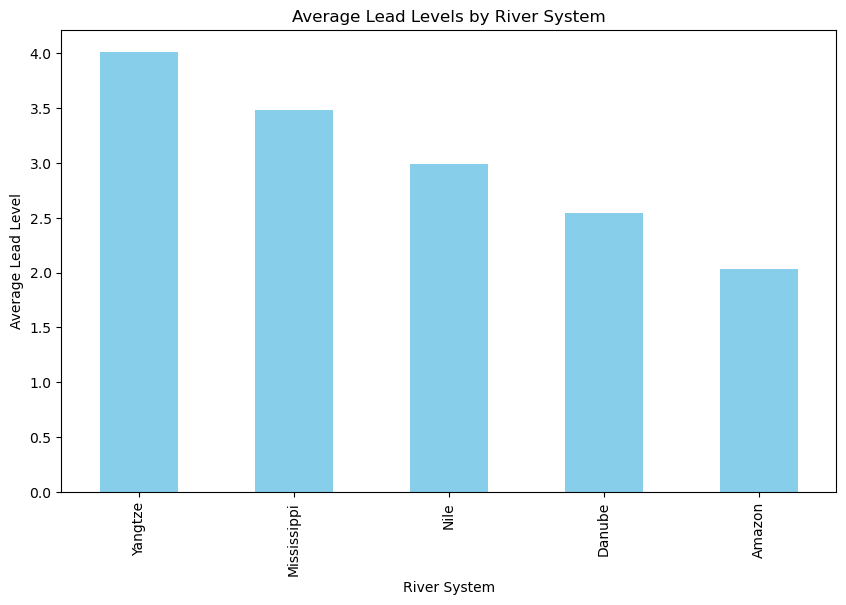

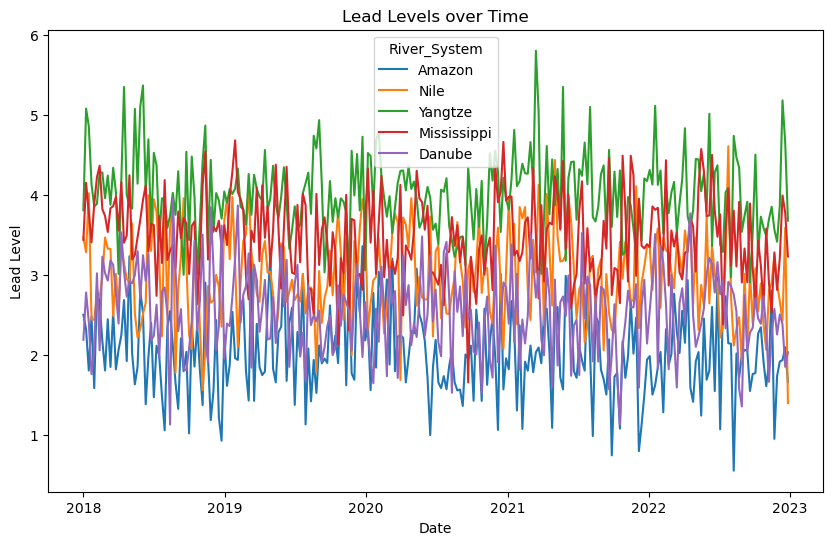

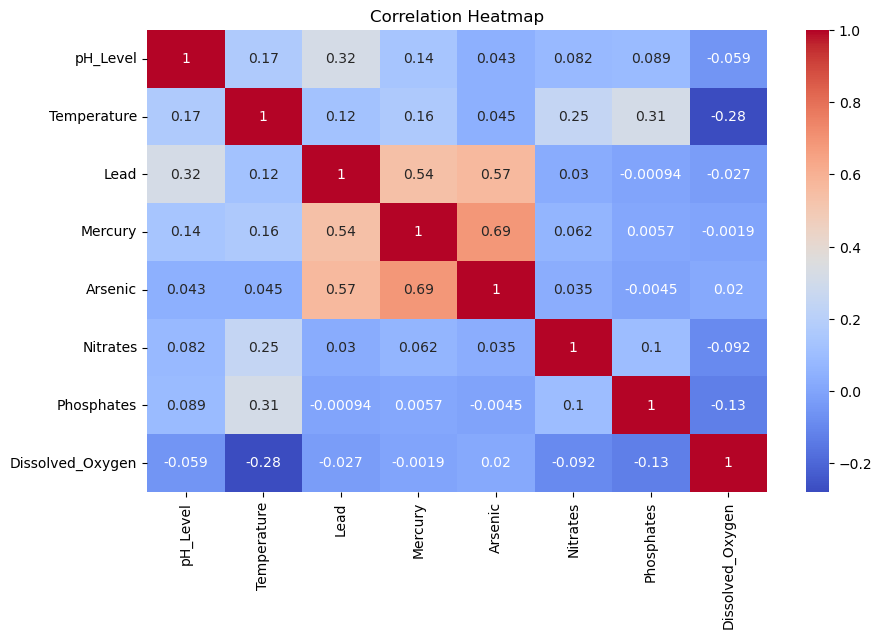

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# load dataset
data = pd.read_csv('C:/Users/iqrab/OneDrive/Desktop/Data Analysis/National_River_Toxin_Dataset_1.csv')

# initial exploration
# print(data.head())
# print(data.info())
# print(data.describe())

# check for missing values
print(data.isnull().sum())
# fill missing values in only numeric columns
numeric_columns = data.select_dtypes(include=[np.number]).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())
data['Date'] = pd.to_datetime(data['Date'])

# calculate average level of toxins
average_toxin_levels = data[['Lead', 'Mercury', 'Arsenic']].mean()
#print(f"Average toxin levels:\n{average_toxin_levels}")

#identify top polluted rivers by average lead levels
top_polluted_rivers = data.groupby('River_System') ['Lead'].mean().sort_values(ascending=False)
# print(f"Top Polluted Rivers:\n{top_polluted_rivers.head()}")

# bar chart for avg lead levels per river
plt.figure(figsize=(10,6))
top_polluted_rivers.plot(kind='bar', color='skyblue')
plt.title('Average Lead Levels by River System')
plt.xlabel('River System')
plt.ylabel('Average Lead Level')
plt.show()

# line graph for toxin levels over time
plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Lead', data = data, hue = 'River_System', errorbar = None)
plt.title('Lead Levels over Time')
plt.xlabel('Date')
plt.ylabel('Lead Level')
plt.show()

# correlation matrix using only numeric columns and heatmap
corr_matrix = data[numeric_columns].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()